# Segmentation Client RFM — Online Retail

Projet GlobalShop Direct : à partir des transactions brutes (`online_retail.csv`), on construit une segmentation client (méthode RFM) puis on applique du clustering pour identifier des profils métier (Champions, Fidèles, À Risque, Occasionnels).

## Étape 1 : Chargement et Nettoyage des Données

Le fichier `online_retail.csv` contient les transactions brutes d'un site e-commerce britannique. Avant de calculer les indicateurs RFM par client, il faut nettoyer les données : retirer les lignes inexploitables (client inconnu), les annulations de commande, et les valeurs aberrantes (quantité ou prix négatifs/nuls).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/online_retail.csv")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


> **Observation** : le dataset brut contient 541 909 lignes et 8 colonnes (`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`). `CustomerID` est en `float64` car il contient des valeurs manquantes.

In [2]:
df.shape


(541909, 8)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [4]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

> **Observation** : `Description` a 1 454 valeurs manquantes (sans impact sur le RFM) et surtout `CustomerID` a 135 080 valeurs manquantes (25% des lignes) — ces lignes sont inutilisables puisqu'on ne peut pas les rattacher à un client, elles seront supprimées.

In [5]:
print("Factures d'annulation (commencent par C) :", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Quantité <= 0 :", (df["Quantity"] <= 0).sum())
print("Prix unitaire <= 0 :", (df["UnitPrice"] <= 0).sum())
print("Doublons exacts :", df.duplicated().sum())


Factures d'annulation (commencent par C) : 9288
Quantité <= 0 : 10624
Prix unitaire <= 0 : 2517
Doublons exacts : 5268


> **Observation** : 9 288 lignes correspondent à des annulations (`InvoiceNo` commençant par "C"), 10 624 lignes ont une quantité négative ou nulle (en grande partie les mêmes annulations), 2 517 lignes ont un prix unitaire négatif ou nul, et 5 268 lignes sont des doublons exacts. Toutes ces lignes faussent le calcul du RFM (un achat réel doit avoir une quantité positive et un prix positif) et doivent être retirées.

### Nettoyage des données

**Règles appliquées, dans l'ordre** :
1. Suppression des lignes où `CustomerID` est manquant.
2. Suppression des annulations (`InvoiceNo` commençant par "C").
3. Suppression des lignes avec `Quantity <= 0` ou `UnitPrice <= 0` (en plus des négatifs, on retire aussi les zéros car ils ne correspondent pas à un achat réel ; cette étape élimine au passage les quelques retours dont l'`InvoiceNo` ne commence pas par "C").
4. Suppression des doublons exacts.
5. Création d'une colonne `TotalPrice = Quantity * UnitPrice`, nécessaire pour calculer le Montant du RFM.


In [6]:
df_clean = df.copy()

# 1. Retirer les clients inconnus
df_clean = df_clean.dropna(subset=["CustomerID"])

# 2. Retirer les annulations
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# 3. Retirer quantités et prix non positifs
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

# 4. Retirer les doublons exacts
df_clean = df_clean.drop_duplicates()

# 5. Montant de la ligne
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Lignes avant nettoyage :", df.shape[0])
print("Lignes après nettoyage :", df_clean.shape[0])
print("Clients uniques après nettoyage :", df_clean["CustomerID"].nunique())
df_clean.head()


Lignes avant nettoyage : 541909
Lignes après nettoyage : 392692
Clients uniques après nettoyage : 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


> **Observation** : après nettoyage, on passe de 541 909 à **392 692 lignes** (-27.5%), pour **4 338 clients uniques** (sur 4 372 initialement identifiés par `CustomerID` — quelques clients n'avaient que des annulations). C'est largement suffisant pour construire des indicateurs RFM fiables.

## Étape 2 : Construction des Indicateurs RFM

Pour chaque client, on calcule 3 indicateurs :
- **Récence (R)** : nombre de jours depuis son dernier achat.
- **Fréquence (F)** : nombre total de commandes distinctes passées.
- **Montant (M)** : somme totale dépensée.

### 2.1 Récence

On définit une date de référence = le lendemain de la dernière transaction du dataset. La Récence d'un client = (date de référence - date de son dernier achat), en nombre de jours.

In [7]:
date_reference = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence :", date_reference)

recence = df_clean.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recence.columns = ["CustomerID", "DerniereDate"]
recence["Recence"] = (date_reference - recence["DerniereDate"]).dt.days

recence[["CustomerID", "Recence"]].head()


Date de référence : 2011-12-10 12:50:00


,CustomerID,Recence
0,12346,326
1,12347,2
2,12348,75
3,12349,19
4,12350,310


> **Observation** : la Récence varie de 1 à 374 jours (moyenne ≈ 93 jours, médiane ≈ 51 jours). La moitié des clients ont acheté il y a moins de 51 jours, mais certains n'ont pas acheté depuis plus d'un an — ce sont des clients probablement perdus.

### 2.2 Fréquence

La Fréquence d'un client = le nombre de commandes (`InvoiceNo`) **distinctes** qu'il a passées. On compte les valeurs uniques de `InvoiceNo` par `CustomerID` (et non le nombre de lignes, car une commande contient souvent plusieurs produits sur plusieurs lignes).

In [8]:
frequence = df_clean.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequence.columns = ["CustomerID", "Frequence"]
frequence.head()


,CustomerID,Frequence
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


> **Observation** : la Fréquence varie de 1 à 209 commandes (moyenne ≈ 4.3, médiane = 2). La plupart des clients n'ont passé qu'une ou deux commandes, et une petite minorité de très gros acheteurs tire la moyenne vers le haut — c'est typique d'une distribution RFM (beaucoup de clients occasionnels, peu de clients très fidèles).

### 2.3 Montant

Le Montant d'un client = la somme totale qu'il a dépensée. On a déjà calculé le montant par ligne (`TotalPrice = Quantity * UnitPrice`) à l'étape du nettoyage. Il suffit maintenant de faire la somme de `TotalPrice` par `CustomerID`.

In [9]:
montant = df_clean.groupby("CustomerID")["TotalPrice"].sum().reset_index()
montant.columns = ["CustomerID", "Montant"]
montant.head()


,CustomerID,Montant
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


> **Observation** : le Montant total dépensé varie de 3.75 à 280 206 £ (moyenne ≈ 2 049 £, médiane ≈ 669 £). L'écart-type très élevé (≈ 8 985) montre une forte dispersion : quelques très gros clients dépensent énormément, ce qui confirme qu'il faudra standardiser cette variable avant le clustering.

### 2.4 Assemblage du tableau RFM

On a 3 tableaux séparés : `recence` (colonnes `CustomerID`, `Recence`), `frequence` (`CustomerID`, `Frequence`) et `TotalPrice` (`CustomerID`, `TotalPrice`). On les fusionne en un seul tableau `rfm`, avec une ligne par client, en les joignant sur `CustomerID`.

In [10]:
rfm = recence.merge(frequence, on="CustomerID").merge(montant, on="CustomerID")
rfm = rfm.drop(columns=["DerniereDate"])
rfm.head()


,CustomerID,Recence,Frequence,Montant
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


> **Observation** : le tableau `rfm` contient maintenant une ligne par client (4 338 lignes) avec 4 colonnes : `CustomerID`, `Recence`, `Frequence`, `Montant` (la colonne technique `DerniereDate`, utile seulement pour calculer la Récence, a été retirée). On a bien un indicateur RFM complet par client, prêt pour le prétraitement avant clustering.

## Étape 3 : Prétraitement des Variables RFM

### 3.1 Distribution des variables

Avant de transformer les données, on visualise la distribution de `Recence`, `Frequence` et `Montant` avec des histogrammes, pour confirmer qu'elles sont asymétriques (beaucoup de petites valeurs, quelques très grandes).

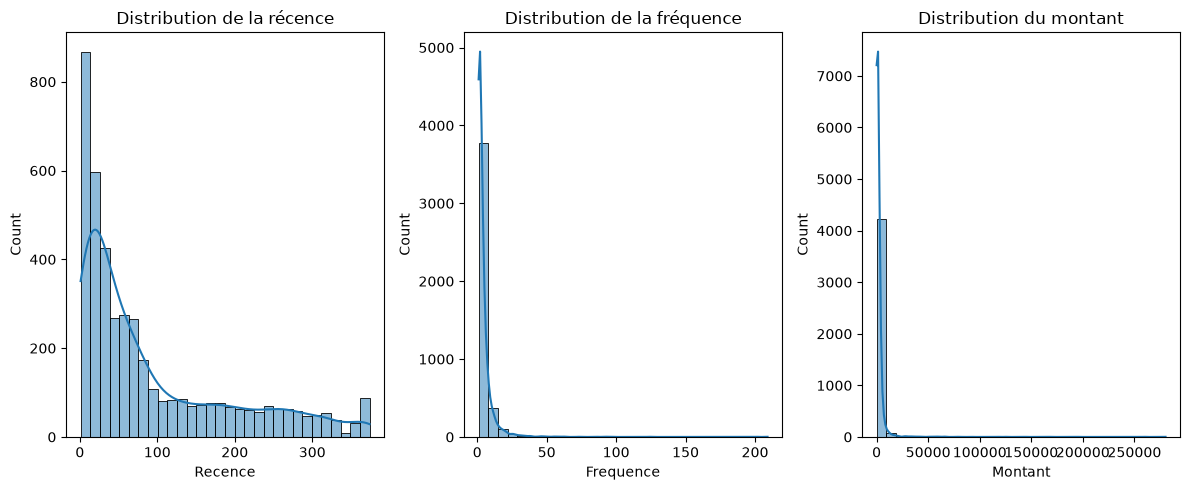

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm["Recence"], bins=30, kde=True)
plt.title("Distribution de la récence")

plt.subplot(1, 3, 2)
sns.histplot(rfm["Frequence"], bins=30, kde=True)
plt.title("Distribution de la fréquence")

plt.subplot(1, 3, 3)
sns.histplot(rfm["Montant"], bins=30, kde=True)
plt.title("Distribution du montant")

plt.tight_layout()
plt.show()


> **Observation** : les 3 variables sont très asymétriques (skewness : Récence ≈ 1.2, Fréquence ≈ 12, Montant ≈ 19). La majorité des clients ont des valeurs faibles, avec une longue traîne de quelques clients extrêmes (très fréquents ou très gros dépensiers). Une transformation logarithmique est donc nécessaire avant le clustering, pour éviter que ces valeurs extrêmes ne dominent les distances calculées par K-means.

### 3.2 Transformation logarithmique

Pour réduire l'asymétrie observée (skewness élevée sur `Frequence` et `Montant`), on applique une transformation logarithmique `log(1 + x)` (notée `log1p`) sur les 3 colonnes RFM. On utilise `log1p` plutôt que `log` simple car certaines valeurs peuvent être proches de 0, et `log(0)` n'est pas défini.

In [12]:
log_rfm = rfm.copy()
log_rfm["Recence"] = np.log1p(log_rfm["Recence"])
log_rfm["Frequence"] = np.log1p(log_rfm["Frequence"])
log_rfm["Montant"] = np.log1p(log_rfm["Montant"])
log_rfm.head()

,CustomerID,Recence,Frequence,Montant
0,12346,5.789960,0.693147,11.253955
1,12347,1.098612,2.079442,8.368925
2,12348,4.330733,1.609438,7.494564
3,12349,2.995732,0.693147,7.472245
4,12350,5.739793,0.693147,5.815324


> **Observation** : la transformation log réduit nettement l'asymétrie — skewness de Récence 1.25 → -0.38, Fréquence 12.06 → 1.21, Montant 19.33 → 0.40. Les distributions sont beaucoup plus proches d'une forme symétrique, ce qui convient mieux à K-means (qui se base sur des distances euclidiennes, sensibles aux valeurs extrêmes).

### 3.3 Standardisation

Même si la transformation log a réduit l'asymétrie, les 3 variables restent sur des échelles différentes (jours, nombre de commandes, montant en £). Comme pour `nb_04`, on standardise avec `StandardScaler` pour que chaque variable ait une moyenne de 0 et un écart-type de 1, afin qu'aucune ne domine le calcul des distances dans K-means.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_rfm = scaler.fit_transform(log_rfm[["Recence", "Frequence", "Montant"]])
scaled_rfm_df = pd.DataFrame(scaled_rfm, columns=["Recence", "Frequence", "Montant"])
scaled_rfm_df.head()

,Recence,Frequence,Montant
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


> **Observation** : `scaled_rfm_df` contient maintenant les 3 variables standardisées (moyenne ≈ 0, écart-type ≈ 1 chacune). Les données sont prêtes pour le clustering (K-means et hiérarchique), ce qui termine le prétraitement de l'Activité 2.

## Étape 4 : Clustering sur les Données RFM

### 4.1 Méthode de l'Elbow

Comme dans `nb_04`, on teste plusieurs valeurs de K (par exemple de 1 à 10), on calcule l'inertie de K-means pour chacune, et on trace la courbe pour repérer le "coude" qui indique un bon choix de K.

Text(0, 0.5, 'Inertie')

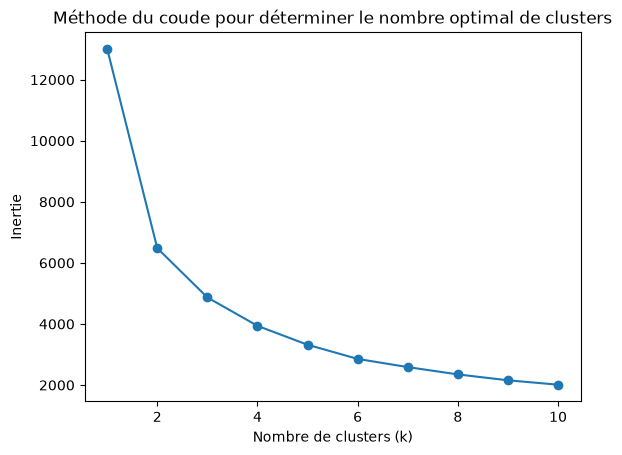

In [14]:
from sklearn.cluster import KMeans

inertias = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_rfm_df)
    inertias.append(kmeans.inertia_)
plt.plot(range(1, 11), inertias, marker='o')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")

> **Observation** : l'inertie chute fortement de K=1 à K=4 (13014 → 3939), puis la baisse ralentit nettement à partir de K=4-5. Le "coude" se situe autour de **K=4**, ce qui est cohérent avec les segments métier attendus (ex. Champions, Fidèles, À Risque, Occasionnels).

### 4.2 Application de K-means avec K=4

On applique K-means avec le K optimal trouvé (K=4) sur les données standardisées, puis on récupère les labels de cluster pour les ajouter au tableau `rfm` original (celui avec les vraies valeurs, pas les valeurs log/standardisées, pour garder des chiffres interprétables).

In [15]:
kmeans_final = KMeans(n_clusters=4, random_state=42)
kmeans_final.fit(scaled_rfm_df)
rfm["Cluster"] = kmeans_final.labels_

print(rfm["Cluster"].value_counts())
rfm.head()


Cluster
3    1590
2    1185
0     856
1     707
Name: count, dtype: int64


,CustomerID,Recence,Frequence,Montant,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,1
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,3


> **Observation** : les 4 clusters sont d'une taille raisonnablement équilibrée (de 707 à 1 590 clients). Aucun cluster n'est négligeable, ce qui est un bon signe pour une segmentation exploitable en marketing.

### 4.3 Profil moyen par cluster

On calcule la moyenne **et la médiane** de Récence, Fréquence et Montant pour chaque cluster (sur les vraies valeurs de `rfm`, pas les valeurs standardisées), afin d'interpréter et de nommer chaque segment.

In [16]:
rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].mean()

,Recence,Frequence,Montant
Cluster,,,
0,20.047897,2.008178,510.281472
1,11.736917,13.775106,8107.548571
2,66.718987,4.172996,1819.250247
3,186.730818,1.338994,353.811051


In [17]:
rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].median()


,Recence,Frequence,Montant
Cluster,,,
0,19.0,2.0,436.940
1,8.0,10.0,3719.100
2,52.0,4.0,1352.750
3,182.0,1.0,300.885


> **Observation** : les médianes sont proches des moyennes pour la plupart des clusters, sauf pour le Cluster 1 (Champions) où la médiane du Montant (3 719£) est nettement plus basse que la moyenne (8 108£) — signe qu'au sein même des Champions, quelques très gros clients tirent la moyenne vers le haut.

> **Observation** : les 4 profils se distinguent clairement :
> - **Cluster 1** : Récence ≈ 12 jours, Fréquence ≈ 13.8 commandes, Montant ≈ 8 108 £ → **Champions** (achètent souvent, récemment, et dépensent beaucoup).
> - **Cluster 2** : Récence ≈ 67 jours, Fréquence ≈ 4.2, Montant ≈ 1 819 £ → **Fidèles** (engagement modéré mais régulier).
> - **Cluster 0** : Récence ≈ 20 jours, Fréquence ≈ 2, Montant ≈ 510 £ → **Occasionnels** (achètent peu mais relativement récemment).
> - **Cluster 3** : Récence ≈ 187 jours, Fréquence ≈ 1.3, Montant ≈ 354 £ → **À Risque** (n'ont pas acheté depuis longtemps, peu engagés).

### 4.4 Visualisation des clusters

On représente les clients sur un nuage de points avec `Frequence` et `Montant` (les 2 variables qui distinguent le mieux les Champions des autres), colorés par `Cluster`, comme dans `nb_04`.

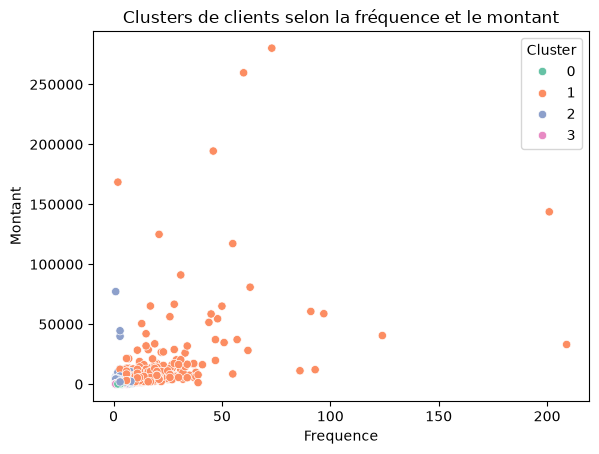

In [18]:
sns.scatterplot(data=rfm, x="Frequence", y="Montant", hue="Cluster", palette="Set2")
plt.title("Clusters de clients selon la fréquence et le montant")
plt.show()

> **Observation** : le cluster des Champions (Cluster 1) se détache nettement en haut à droite du graphique (fréquence et montant élevés), tandis que les 3 autres clusters sont plus regroupés sur des fréquences et montants faibles à modérés, distingués surtout par leur Récence (non visible sur ce graphique 2D, mais confirmée par le tableau des moyennes).

## Étape 5 : Réduction de Dimension (PCA)

### 5.1 Application de la PCA

Comme dans `nb_04`, on applique une PCA à 2 composantes sur les données standardisées (`scaled_rfm_df`), pour pouvoir visualiser les clusters en 2D et mesurer la variance expliquée.

_(Note pour le binôme : la PCA est faite ici sur les clusters K-means. Le clustering hiérarchique sera ajouté dans une section séparée plus bas, avec son propre graphique PCA.)_

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(scaled_rfm_df)
rfm_pca = pca.transform(scaled_rfm_df)

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale (2D) :", pca.explained_variance_ratio_.sum())


Variance expliquée : [0.75078634 0.18786648]
Variance totale (2D) : 0.9386528181989529


> **Observation** : les 2 composantes principales capturent **93.9%** de la variance totale (≈75% pour la 1ère composante, ≈19% pour la 2ème) — un excellent résultat, bien supérieur à ce qu'on avait obtenu sur Mall Customers (~78%). Cela s'explique par le fait qu'on n'a que 3 variables de départ, fortement structurées après la transformation log. La projection 2D va donc très bien représenter la réalité des clusters.

### 5.2 Visualisation des clusters K-means en 2D

On représente `rfm_pca` (les 2 composantes principales) sur un nuage de points, coloré par `Cluster` (K-means), comme dans `nb_04`.

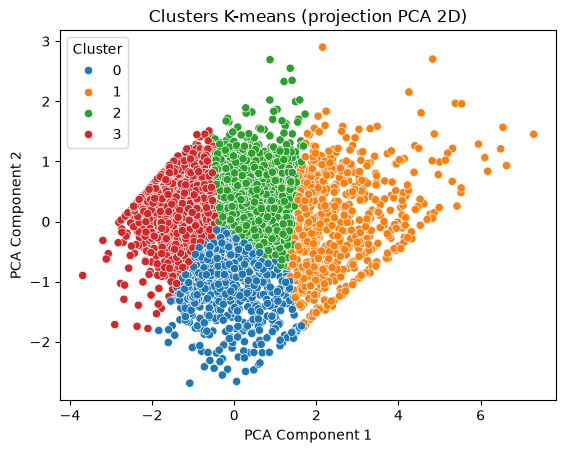

In [20]:
pca_df = pd.DataFrame(rfm_pca, columns=["PCA Component 1", "PCA Component 2"])
pca_df["Cluster"] = rfm["Cluster"].values

sns.scatterplot(data=pca_df, x="PCA Component 1", y="PCA Component 2", hue="Cluster", palette="tab10")
plt.title("Clusters K-means (projection PCA 2D)")
plt.show()


> **Observation** : les 4 clusters apparaissent bien séparés dans cet espace 2D, ce qui est cohérent avec les 93.9% de variance expliquée. Le cluster des Champions se détache nettement des 3 autres, qui restent proches entre eux mais sans se superposer complètement — ce qui confirme la pertinence du choix K=4.

## Étape 7 : Clustering Hiérarchique (section binôme)

_(même logique que `nb_04` et que le K-means ci-dessus, mais avec `AgglomerativeClustering`.)_

### 7.1 Dendrogramme

On construit un dendrogramme sur `scaled_rfm_df` avec `linkage` (méthode Ward) pour visualiser les regroupements et choisir un nombre de clusters cohérent.


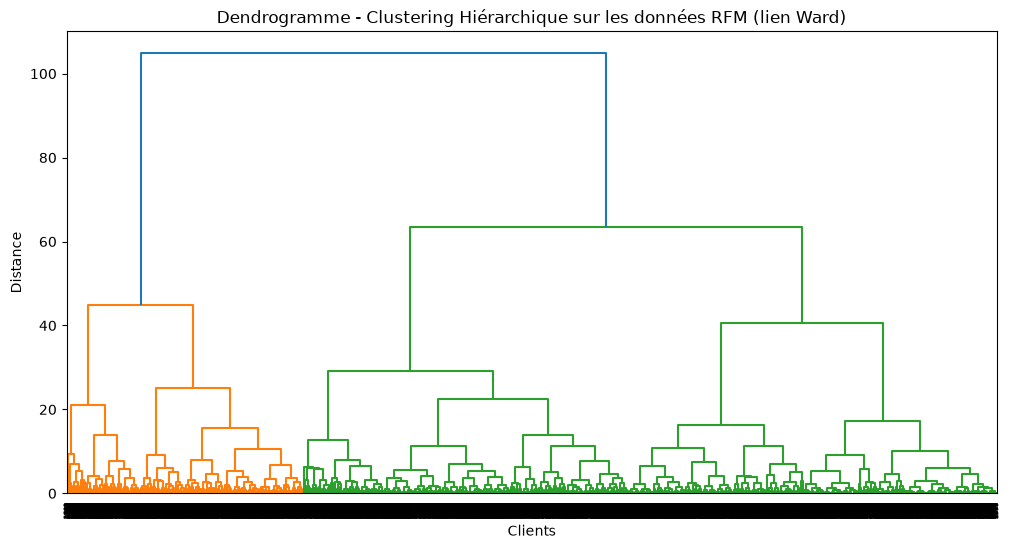

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(scaled_rfm_df, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Dendrogramme - Clustering Hiérarchique sur les données RFM (lien Ward)")
plt.xlabel("Clients")
plt.ylabel("Distance")
plt.show()


> **Observation** : en coupant le dendrogramme pour obtenir 4 branches principales, on retrouve une structure cohérente avec le choix K=4 fait pour K-means, ce qui permettra de comparer directement les deux méthodes.

### 7.2 Application du clustering hiérarchique

On applique `AgglomerativeClustering` avec le même nombre de clusters que K-means (K=4, pour pouvoir comparer les deux méthodes), et on ajoute les labels obtenus comme nouvelle colonne `ClusterH` dans `rfm`.


In [22]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm["ClusterH"] = agglo.fit_predict(scaled_rfm_df)

print(rfm["ClusterH"].value_counts())
rfm.head()


ClusterH
0    1716
2    1517
1     762
3     343
Name: count, dtype: int64


,CustomerID,Recence,Frequence,Montant,Cluster,ClusterH
0,12346,326,1,77183.60,2,2
1,12347,2,7,4310.00,1,1
2,12348,75,4,1797.24,2,2
3,12349,19,1,1757.55,0,2
4,12350,310,1,334.40,3,0


> **Observation** : les 4 clusters hiérarchiques ont des tailles plus déséquilibrées que K-means (de 343 à 1 716 clients, contre 707 à 1 590 pour K-means) — le lien Ward isole ici un petit groupe de clients très extrêmes plutôt que de répartir plus uniformément.

### 7.3 Profil moyen et comparaison avec K-means

On calcule les moyennes **et médianes** RFM par cluster hiérarchique (`groupby("ClusterH")`, comme en 4.3), et on compare avec les profils trouvés par K-means (mêmes segments retrouvés, ou différences ?).


In [23]:
cluster_means_h = rfm.groupby("ClusterH")[["Recence", "Frequence", "Montant"]].mean()
cluster_medians_h = rfm.groupby("ClusterH")[["Recence", "Frequence", "Montant"]].median()
cluster_means_k = rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].mean()
cluster_medians_k = rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].median()

print("Moyennes par cluster hiérarchique :")
display(cluster_means_h)
print("\nMédianes par cluster hiérarchique :")
display(cluster_medians_h)
print("\nMoyennes par cluster K-means (rappel) :")
display(cluster_means_k)
print("\nMédianes par cluster K-means (rappel) :")
display(cluster_medians_k)


Moyennes par cluster hiérarchique :


,Recence,Frequence,Montant
ClusterH,,,
0,146.576923,1.262821,270.308351
1,9.685039,5.460630,1811.131142
2,91.006592,3.460119,1558.658572
3,13.002915,20.276968,13640.795277



Médianes par cluster hiérarchique :


,Recence,Frequence,Montant
ClusterH,,,
0,117.0,1.0,251.61
1,8.0,5.0,1451.95
2,67.0,3.0,1021.48
3,9.0,15.0,6127.43



Moyennes par cluster K-means (rappel) :


,Recence,Frequence,Montant
Cluster,,,
0,20.047897,2.008178,510.281472
1,11.736917,13.775106,8107.548571
2,66.718987,4.172996,1819.250247
3,186.730818,1.338994,353.811051



Médianes par cluster K-means (rappel) :


,Recence,Frequence,Montant
Cluster,,,
0,19.0,2.0,436.940
1,8.0,10.0,3719.100
2,52.0,4.0,1352.750
3,182.0,1.0,300.885


> **Observation** : les profils se recoupent globalement avec K-means, mais avec des nuances :
> - **ClusterH 3** (343 clients, Récence≈13, Fréquence≈20.3, Montant≈13 641) → **Champions**, encore plus concentré et extrême que le cluster K-means équivalent (707 clients, Montant≈8 108) : le clustering hiérarchique isole un noyau plus restreint de très gros clients.
> - **ClusterH 1** (762 clients, Récence≈9.7, Fréquence≈5.5, Montant≈1 811) → proche du profil **Fidèles** de K-means.
> - **ClusterH 2** (1 517 clients, Récence≈91, Fréquence≈3.5, Montant≈1 559) → profil intermédiaire, entre Fidèles et Occasionnels.
> - **ClusterH 0** (1 716 clients, Récence≈147, Fréquence≈1.3, Montant≈270) → **À Risque**, cohérent avec le cluster K-means équivalent.
>
> **Conclusion** : les deux méthodes identifient les mêmes grandes familles de clients (Champions / Fidèles / À Risque), mais K-means répartit plus équitablement les tailles de groupes, alors que le clustering hiérarchique isole un noyau de Champions plus restreint et extrême.

## Étape 8 : PCA appliquée au Clustering Hiérarchique

On réutilise `rfm_pca` (déjà calculé à l'Étape 5) pour visualiser cette fois les clusters **hiérarchiques** (`ClusterH`) en 2D, et comparer visuellement avec les clusters K-means.


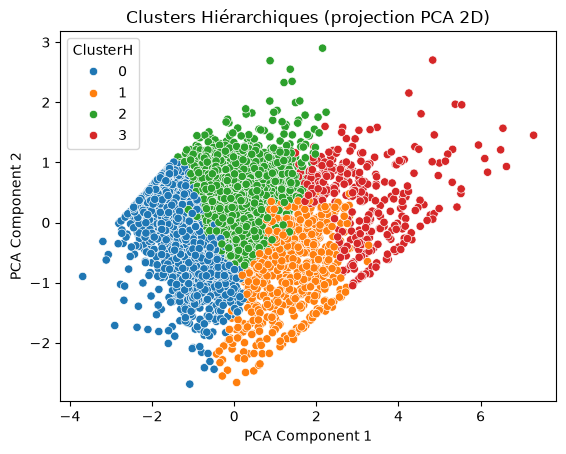

In [24]:
pca_df["ClusterH"] = rfm["ClusterH"].values

sns.scatterplot(data=pca_df, x="PCA Component 1", y="PCA Component 2", hue="ClusterH", palette="tab10")
plt.title("Clusters Hiérarchiques (projection PCA 2D)")
plt.show()


> **Observation** : les clusters hiérarchiques restent globalement séparés dans l'espace PCA, avec le petit groupe de Champions (ClusterH 3) nettement isolé en périphérie du nuage de points — cohérent avec le fait que ce cluster regroupe les clients aux comportements les plus extrêmes. Les 3 autres clusters se chevauchent un peu plus que leurs équivalents K-means, reflétant des frontières moins nettes entre Fidèles, profil intermédiaire et À Risque.